In [1]:
import pandas as pd

df = pd.read_csv(r"D:\ML Projects\ML-Customer-Churn-Pipeline\data\raw\churn_data.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
import sys
import os
import importlib

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import src.data.preprocessing as preprocessing
importlib.reload(preprocessing)
from src.data.preprocessing import clean_data
from src.features.build_features import build_features

if df is None:
    raise ValueError("df is None — re-run the cell that loads churn_data.csv first")

df = clean_data(df)
df = build_features(df)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,tenure_group,num_services,has_support,is_engaged,avg_monthly_spend,is_monthly_contract,uses_electronic_check,has_family
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,29.85,0,new,1,0,0,14.925000,1,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,mid-term,3,1,0,53.985714,0,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,new,3,1,0,36.050000,1,0,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,1840.75,0,mid-term,3,1,0,40.016304,0,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,new,1,0,0,50.550000,1,1,0


In [5]:
df.isnull().sum()

gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn                    0
tenure_group             0
num_services             0
has_support              0
is_engaged               0
avg_monthly_spend        0
is_monthly_contract      0
uses_electronic_check    0
has_family               0
dtype: int64

In [6]:
# distribution of new features
df['tenure_group'].value_counts()

tenure_group
long-term     2239
new           2175
mid-term      1594
short_term    1024
Name: count, dtype: int64

In [7]:
df['num_services'].value_counts()

num_services
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
0      80
Name: count, dtype: int64

In [8]:
df['is_monthly_contract'].value_counts()

is_monthly_contract
1    3875
0    3157
Name: count, dtype: int64

In [9]:
# running preprocessing for training
from src.models.train import prepare_data

X_train, X_test, y_train, y_test, preprocessor = prepare_data(df)

print(X_train.shape)
print(X_test.shape)

(5625, 49)
(1407, 49)


In [10]:
import importlib
import src.models.train as train_module
importlib.reload(train_module)
from src.models.train import train_logistic_regression, train_random_forest, train_XGB, evaluate_model

# LR model
lr_model = train_logistic_regression(X_train, y_train)
print("Logistic Regression Results:")
evaluate_model(lr_model, X_test, y_test)

# RF model
rf_model = train_random_forest(X_train, y_train)
print("\nRandom Forest Classifier Results:")
evaluate_model(rf_model, X_test, y_test)

# XGB model
xgb_model = train_XGB(X_train, y_train)
print("\nXGB Classifier Results:")
evaluate_model(xgb_model, X_test, y_test)

d:\ML Projects\ML-Customer-Churn-Pipeline\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results:
Accuracy:  0.7306325515280739

Classification Report
               precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407


Random Forest Classifier Results:
Accuracy:  0.7882018479033405

Classification Report
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


XGB Classifier Results:
Accuracy:  0.7761194029850746

Classification Report
               precision    recall  f1-score   support

           0       0.84      0.86      0

In [11]:
# feature explainability
feature_names = preprocessor.get_feature_names_out()

coefficients = lr_model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

feature_importance = feature_importance.sort_values(
    by='coefficient',
    ascending = False
)

feature_importance.head(10)

,feature,coefficient
25,cat__Contract_Month-to-month,0.508888
46,num__is_monthly_contract,0.508888
6,cat__PhoneService_No,0.400782
11,cat__InternetService_Fiber optic,0.215720
38,num__SeniorCitizen,0.211668
9,cat__MultipleLines_Yes,0.197156
26,cat__Contract_One year,0.163072
47,num__uses_electronic_check,0.155481
32,cat__PaymentMethod_Electronic check,0.155481
34,cat__tenure_group_long-term,0.151362


In [12]:
feature_importance.tail(10)

,feature,coefficient
28,cat__PaperlessBilling_No,-0.165889
37,cat__tenure_group_short_term,-0.178906
23,cat__StreamingMovies_No,-0.193217
42,num__num_services,-0.196145
21,cat__StreamingTV_No,-0.206522
12,cat__InternetService_No,-0.213052
43,num__has_support,-0.222544
8,cat__MultipleLines_No,-0.264273
7,cat__PhoneService_Yes,-0.467899
27,cat__Contract_Two year,-0.739078


In [13]:
import sys
!{sys.executable} -m pip install shap

'd:\ML' is not recognized as an internal or external command,
operable program or batch file.


In [15]:
from src.explainability.shap_analysis import run_shap_analysis
explainer, shap_values, X_train_df = run_shap_analysis(
    xgb_model,
    X_train,
    feature_names
)

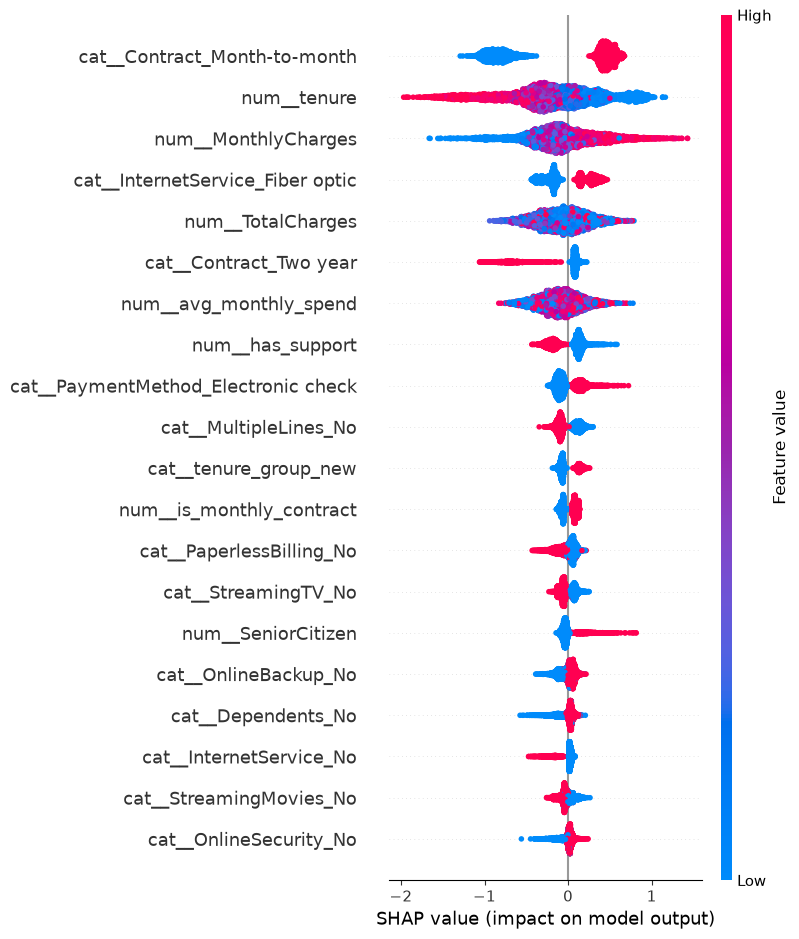

In [16]:
import shap

shap.summary_plot(shap_values, X_train_df)

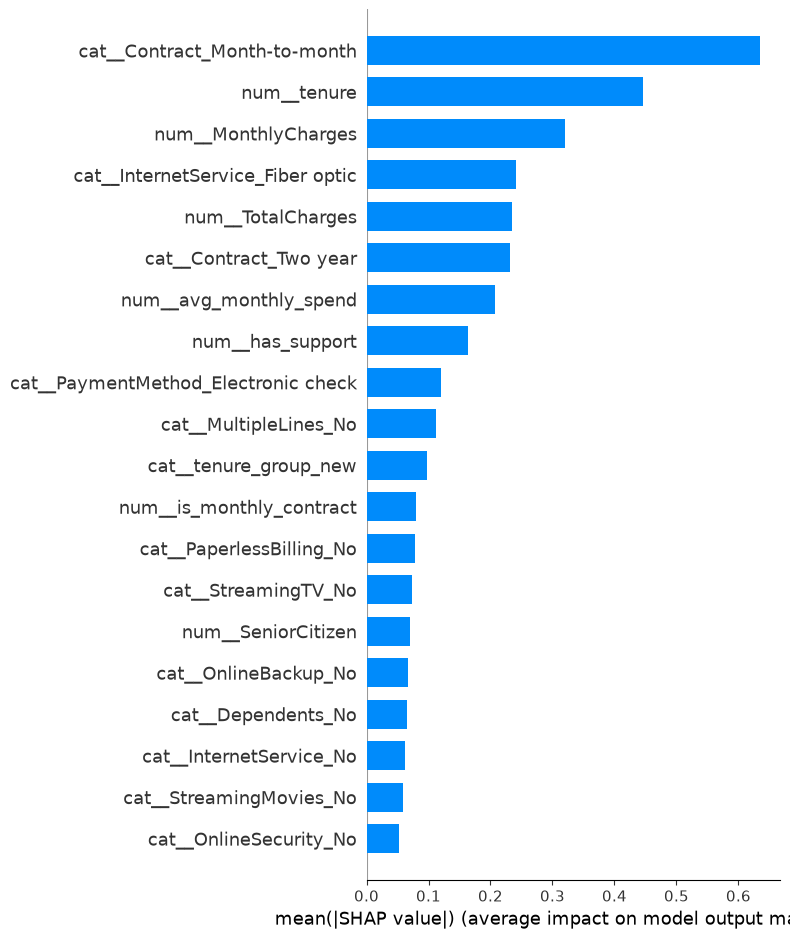

In [17]:
shap.summary_plot(shap_values, X_train_df, plot_type="bar")

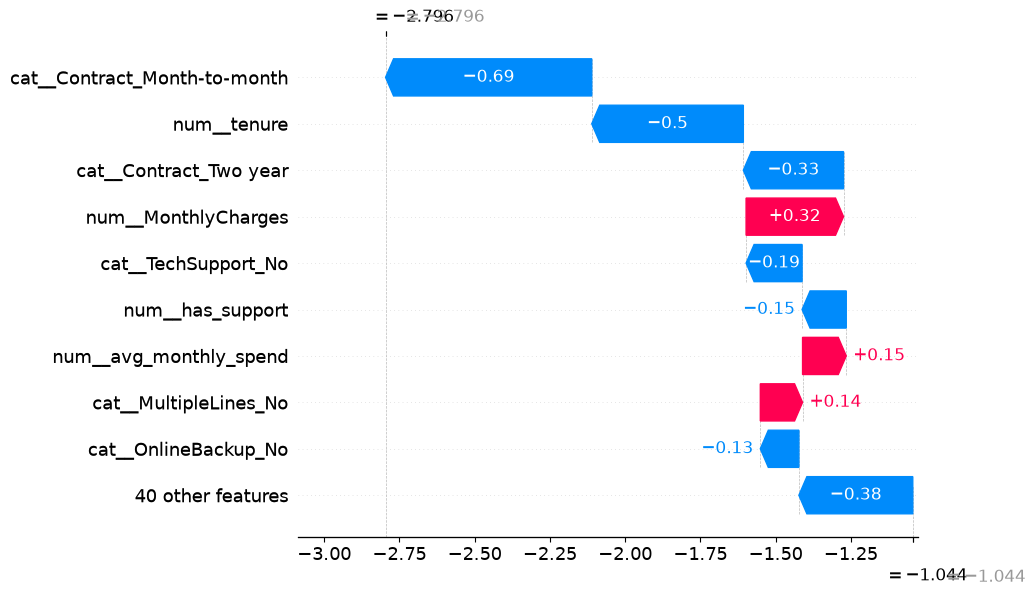

In [18]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names
)